# Diabetes Health Indicators — Model Evaluation

Dataset: CDC BRFSS2015 Diabetes Health Indicators, 50/50 balanced binary split
(`diabetes_binary_5050split_health_indicators_BRFSS2015.csv`).

Target: `Diabetes_binary` (0 = no diabetes, 1 = prediabetes/diabetes).

This notebook covers:
1. Data loading & exploration
2. Preprocessing (train/test split, feature scaling)
3. Model training with optimization techniques (Adam optimizer, L2
   regularization, early stopping, hyperparameter tuning via grid search)
4. Evaluation with 5 metrics: accuracy, log loss, F1, precision, recall
   (plus confusion matrix and ROC-AUC)
5. Saving the trained model + scaler as the pretrained baseline used by the
   retraining pipeline (`src/train.py`)


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, log_loss, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay,
)

from src.preprocessing import (
    FEATURE_COLUMNS, CONTINUOUS_COLUMNS, TARGET_COLUMN,
    load_raw_csv, fit_scaler, transform_features, save_scaler,
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 1. Load & explore data

In [2]:
DATA_PATH = Path.cwd().parent / "data" / "raw" / "diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
df = load_raw_csv(DATA_PATH)
print(df.shape)
df.head()


(70692, 22)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0,0.0
1,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0,0.0
2,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0,0.0
3,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,1.0,...,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0,0.0
4,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,1.0,...,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0,0.0


In [3]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
HighBP,70692.0,0.563458,0.495960,0.0,0.0,1.0,1.0,1.0
HighChol,70692.0,0.525703,0.499342,0.0,0.0,1.0,1.0,1.0
CholCheck,70692.0,0.975259,0.155336,0.0,1.0,1.0,1.0,1.0
BMI,70692.0,29.856985,7.113954,12.0,25.0,29.0,33.0,98.0
Smoker,70692.0,0.475273,0.499392,0.0,0.0,0.0,1.0,1.0
Stroke,70692.0,0.062171,0.241468,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,70692.0,0.147810,0.354914,0.0,0.0,0.0,0.0,1.0
PhysActivity,70692.0,0.703036,0.456924,0.0,0.0,1.0,1.0,1.0
Fruits,70692.0,0.611795,0.487345,0.0,0.0,1.0,1.0,1.0
Veggies,70692.0,0.788774,0.408181,0.0,1.0,1.0,1.0,1.0


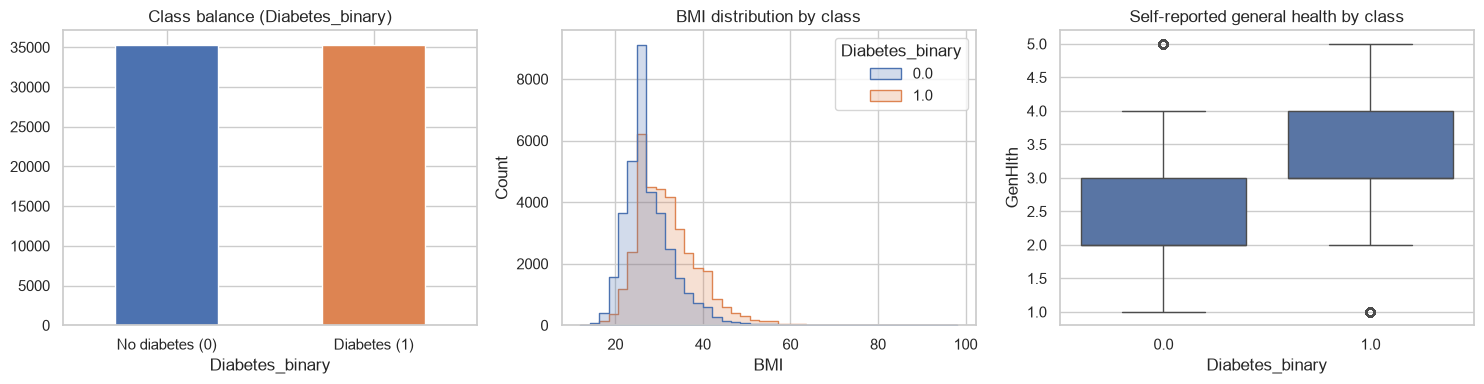

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df[TARGET_COLUMN].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"]
)
axes[0].set_title("Class balance (Diabetes_binary)")
axes[0].set_xticklabels(["No diabetes (0)", "Diabetes (1)"], rotation=0)

sns.histplot(data=df, x="BMI", hue=TARGET_COLUMN, bins=40, ax=axes[1], element="step")
axes[1].set_title("BMI distribution by class")

sns.boxplot(data=df, x=TARGET_COLUMN, y="GenHlth", ax=axes[2])
axes[2].set_title("Self-reported general health by class")

plt.tight_layout()
plt.show()


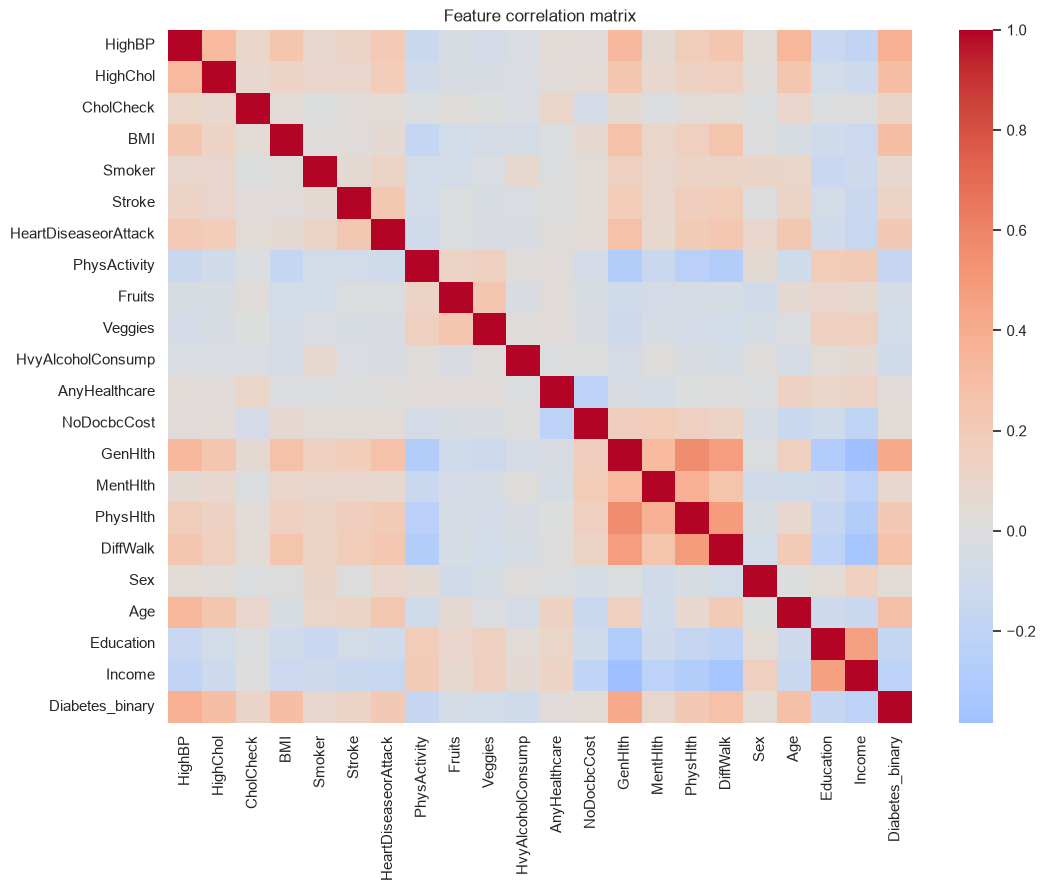

GenHlth                 0.407612
HighBP                  0.381516
BMI                     0.293373
HighChol                0.289213
Age                     0.278738
DiffWalk                0.272646
PhysHlth                0.213081
HeartDiseaseorAttack    0.211523
Stroke                  0.125427
CholCheck               0.115382
MentHlth                0.087029
Smoker                  0.085999
Sex                     0.044413
NoDocbcCost             0.040977
AnyHealthcare           0.023191
Fruits                 -0.054077
Veggies                -0.079293
HvyAlcoholConsump      -0.094853
PhysActivity           -0.158666
Education              -0.170481
Income                 -0.224449
Name: Diabetes_binary, dtype: float64

In [5]:
plt.figure(figsize=(12, 9))
corr = df[FEATURE_COLUMNS + [TARGET_COLUMN]].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Feature correlation matrix")
plt.show()

corr[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(ascending=False)


## 2. Preprocessing

- Stratified train/test split (80/20) to preserve class balance.
- Continuous-ish features (`BMI`, `GenHlth`, `MentHlth`, `PhysHlth`, `Age`,
  `Education`, `Income`) are standardized; the remaining features are
  already binary indicators and are left untouched.
- The fitted `StandardScaler` is saved so the exact same transform is
  reused by the FastAPI prediction endpoint and the retraining pipeline —
  this avoids train/serve skew.


In [6]:
X = df[FEATURE_COLUMNS]
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = fit_scaler(pd.concat([X_train, y_train], axis=1))
X_train_t = transform_features(pd.concat([X_train, y_train], axis=1), scaler)
X_test_t = transform_features(pd.concat([X_test, y_test], axis=1), scaler)

print("train:", X_train_t.shape, "test:", X_test_t.shape)


train: (56553, 21) test: (14139, 21)


## 3. Model training with optimization techniques

Base model: `MLPClassifier` (feed-forward neural network) with:

- **Optimizer**: Adam
- **Regularization**: L2 penalty (`alpha`)
- **Early stopping**: stops training once validation score plateaus,
  preventing overfitting
- **Hyperparameter tuning**: grid search over hidden layer size and `alpha`

`warm_start=True` is set deliberately: the *same* fitted estimator object is
what gets saved to `models/model.pkl` and later reloaded by
`src/train.py` for retraining — calling `.fit()` again on new data continues
optimizing from the existing learned weights instead of starting from a
random initialization, i.e. it is used as a genuine pretrained base model,
not retrained from scratch.


In [7]:
param_grid = {
    "hidden_layer_sizes": [(32,), (64, 32), (64, 32, 16)],
    "alpha": [1e-4, 1e-3, 1e-2],
}

base_estimator = MLPClassifier(
    solver="adam",
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    max_iter=300,
    warm_start=True,
    random_state=RANDOM_STATE,
)

grid = GridSearchCV(
    base_estimator, param_grid, cv=3, scoring="f1", n_jobs=-1, verbose=1
)
grid.fit(X_train_t, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

model = grid.best_estimator_


Fitting 3 folds for each of 9 candidates, totalling 27 fits


Best params: {'alpha': 0.001, 'hidden_layer_sizes': (32,)}
Best CV F1: 0.7666594768000934


## 4. Evaluation

In [8]:
y_pred = model.predict(X_test_t)
y_proba = model.predict_proba(X_test_t)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "log_loss": log_loss(y_test, y_proba),
    "f1_score": f1_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
}
for k, v in metrics.items():
    print(f"{k:12s}: {v:.4f}")

print()
print(classification_report(y_test, y_pred, target_names=["No diabetes", "Diabetes"]))


accuracy    : 0.7503
log_loss    : 0.5017
f1_score    : 0.7607
precision   : 0.7302
recall      : 0.7939
roc_auc     : 0.8304

              precision    recall  f1-score   support

 No diabetes       0.77      0.71      0.74      7070
    Diabetes       0.73      0.79      0.76      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



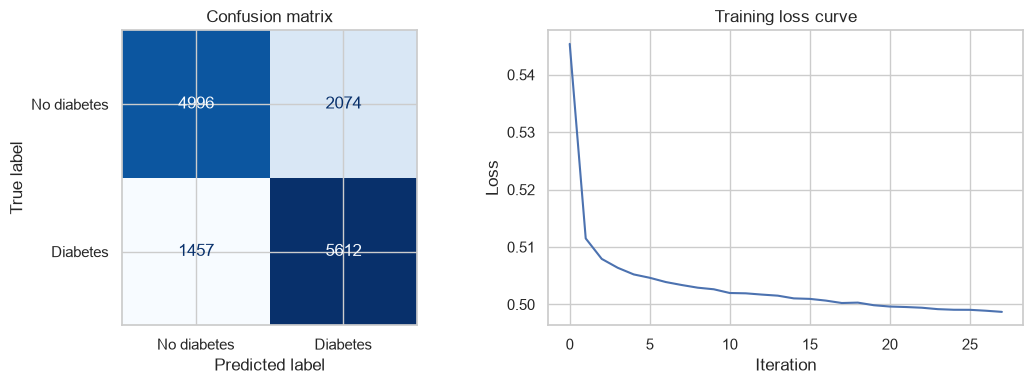

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred), display_labels=["No diabetes", "Diabetes"]
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion matrix")

axes[1].plot(model.loss_curve_)
axes[1].set_title("Training loss curve")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()


## 5. Save the pretrained baseline

These artifacts are the "pretrained model" referenced by the retraining
pipeline (`src/train.py`): new uploaded data is used to fine-tune this
exact model via `warm_start`, not to train a fresh one.


In [10]:
MODELS_DIR = Path.cwd().parent / "models"
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump(model, MODELS_DIR / "model.pkl")
save_scaler(scaler, MODELS_DIR / "scaler.pkl")

metrics_out = {**metrics, "best_params": grid.best_params_, "n_train": len(X_train_t), "n_test": len(X_test_t)}
with open(MODELS_DIR / "metrics.json", "w") as f:
    json.dump(metrics_out, f, indent=2)

print("Saved model, scaler, metrics to", MODELS_DIR)
metrics_out


Saved model, scaler, metrics to C:\Users\hb\diabetes-predictor-pipeline\models


{'accuracy': 0.7502652238489285,
 'log_loss': 0.5017263257842299,
 'f1_score': 0.7606912910877669,
 'precision': 0.7301587301587301,
 'recall': 0.7938888102984863,
 'roc_auc': 0.8303608820150854,
 'best_params': {'alpha': 0.001, 'hidden_layer_sizes': (32,)},
 'n_train': 56553,
 'n_test': 14139}